# Introduction

Glass is used everywhere in our daily life, such as building window glass, car window glass and so on. However, these glasses are not identical. Due to their different uses, there are some differences in their physical and chemical properties, and these differences come from the different chemical compositions of the glass. The aim of this project is to use the chemical composition of glass to build a classification model to determine the type of glass, such as architectural window glass, car window glass, containers glass, and so on. In addition , this project also has practical applications, such as the identification of the source of broken glass for forensic identification, or for automated separation in waste recycling and material categorization.


I will try different supervised learning models, including one-versus-all logistics regression, support vector machine, random forest, and so on, with comparisons of the results of each model. In addition to the modeling itself, I will also discuss the strengths and weaknesses of the models in the context of actual performance.

# Data Overview

The dataset used was the Glass Identification dataset from the UCI Machine Learning Library [1]. This dataset contains the refractive index (RI) of the glass and the concentration of various elements (e.g., Na, Mg, Al, Si, K, Ca, Ba, Fe), and the target variable is the type of glass (6 categories in total).

In [30]:
# import data
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
glass_identification = fetch_ucirepo(id=42) 
  
# data (as pandas dataframes) 
X = glass_identification.data.features 
y = glass_identification.data.targets 

In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
dtypes: float64(9)
memory usage: 15.2 KB


Based on this output, there is no mising value found in `X`.

In [6]:
X.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000
25%,1.516523,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000


In [7]:
X.head(10)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.00
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.00
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.00
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.00
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.00
5,1.51596,12.79,3.61,1.62,72.97,0.64,8.07,0.0,0.26
6,1.51743,13.30,3.60,1.14,73.09,0.58,8.17,0.0,0.00
7,1.51756,13.15,3.61,1.05,73.24,0.57,8.24,0.0,0.00
8,1.51918,14.04,3.58,1.37,72.08,0.56,8.30,0.0,0.00
9,1.51755,13.00,3.60,1.36,72.99,0.57,8.40,0.0,0.11


Features:
- RI: refractive index of the glass
- Na: Sodium (unit: weight percent in corresponding oxide)
- Mg: Magnesium (unit: weight percent in corresponding oxide)
- Al: Aluminum (unit: weight percent in corresponding oxide)
- Si: Silicon (unit: weight percent in corresponding oxide)
- K: Potassium (unit: weight percent in corresponding oxide)
- Ca: Calcium (unit: weight percent in corresponding oxide)
- Ba: Barium (unit: weight percent in corresponding oxide)
- Fe: Iron (unit: weight percent in corresponding oxide)

In [8]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Type_of_glass  214 non-null    int64
dtypes: int64(1)
memory usage: 1.8 KB


Based on this output, there is no missing value found in `y`. Therefore, there is no missing value found in the entire dataset.

In [4]:
y.head(10)

,Type_of_glass
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1


In [12]:
y.value_counts().sort_index()

Type_of_glass
1                70
2                76
3                17
5                13
6                 9
7                29
dtype: int64

Type of glass: (class attribute)
- 1: building windows float processed
- 2: building windows non-float processed
- 3: vehicle windows float processed
- 5: containers
- 6: tableware
- 7: headlamps

Based on this output, we notice that the distribution of data for the glass type is not uniform. Classes 1 and 2 have significantly more samples than the other classes, while Class 6 has very few samples. This category unbalance may affect the training of the model, which results in some categories being ignored or misclassified in the prediction.

# Data Processing

After getting some basic understanding of this dataset, we started to do some basic processing of the data.
At first, although each feature represents the proportion of a certain element in the glass, they are distributed over a relatively large range of numerical sizes. In order to avoid certain features with a large percentage dominating the model training, we have to standardize the data for the features. Then, we change the shape of class label `y` to make sure it is a 1D arrary `(214,)`. Also, we randomly divide the data into a training set (80%) and a test set (20%) proportionally to prepare for subsequent model training。

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# make sure the shape of y is (n,)
y = y.to_numpy().ravel()
print(y.shape)

# split dataset into train set and test set
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=7)

(214,)


# Models

In this section, I will try multiple supervised learning models to solve this glass classification problem. These include specifically Logistic Regression (OvA), Support Vector Machine (SVM), Random Forest, XGBoost and Neural Network. I will compare their performance on the test set using two uniform evaluation measures, accuracy and f1-score. Each model is evaluated on both training and test sets in order to see if there is any overfitting or underfitting.

The two metrics I have chosen as evaluation criteria are because of their complementary nature. First, accuracy is the most basic and straightforward indicator. It represents the percentage of correctly predicted samples out of the total samples, so it is a strong measure to assess the overall predictive ability of the model.

$$
\text{accuracy} = \frac{\text{the number of correactly predicted sample}}{\text{the number of total sample}}
$$

However, since the number of samples in each class in this dataset is not equally distributed, we also need to take the correctness of each class into consideration. In this case, we can evaluate the correctness of each category by calculating the F1-score [3]. In short, it is a combination of precision and recall. Precision represents how many of all the data predicted by the model to be in a certain class are successfully recognized [3]. Recall means how many of all the data that are actually in a certain class are successfully recognized [3]. Therefore, the F1-score can more fairly reflect the performance of the model on different classes, which is especially suitable for the case of unbalanced class distribution.

$$
F_1\text{-score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$


In particular, there are three different ways of averaging the F1-score, which are macro, micro, and weighted[3]. Among them, the weighted F1-score weights the F1-score according to the number of samples in each class [3]. This better reflects the performance of the model on this unbalanced data, so we will use weighted F1-score as the evaluation measure. 

$$
\text{weighted }F_1\text{-score} = F_{1_{class1}} * W_1 + F_{1_{class2}} * W_2 + \cdots + F_{1_{classN}} * W_N \quad 
$$
$$
\text{where } W_n \text{ is the proportion of class n} \space \forall n \in [1,N].
$$


To summarize, I use a combination of both measures to evaluate the fit of different models.

In [109]:
from sklearn.metrics import accuracy_score, f1_score

def compute_scores(model, X_train, y_train, X_test, y_test):
    
    # fit the model and get predict value
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    
    # accuracy
    acc_test = accuracy_score(y_test, y_pred_test)
    acc_train = accuracy_score(y_train, y_pred_train)
    
    # f1 scores
    f1_test = f1_score(y_test, y_pred_test, average='weighted')
    f1_train = f1_score(y_train, y_pred_train, average='weighted')
    
    return acc_train, acc_test,f1_train,f1_test

In order to evaluate the performance of different models in a uniform way, we define a function `compute_scores()` that computes the accuracy and Weighted F1-score of a model on the training set and the test set respectively. This function not only allows for a quick evaluation of individual models, but also allows for follow-up horizontal comparisons of the results of different models.

## One-versus-All (OvA) Logistic Regression

Since this project is a multi-class classification (there are 6 classes of glass types in total), we used the One-vs-All (OvA) strategy to perform an extension of logistic regression. This method trains a separate two-class classifier for each class to distinguishi this class from the remainder of the data. The advantage of this model is that it is simple, fast, and easy to understand and compute. We use it as a baseline model to see the effect of a simple linear model, and to compare it with more complex models later.

In addition, because this model supports training round by round, we also plot the changes of its accuracy and F1-score under different iterations, which is used to analyze the convergence process of the model.

In [110]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
# ignore warnnings
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# OvA model
model_ova = LogisticRegression(max_iter=1, warm_start=True, multi_class='ovr', random_state=7)

n_iter = 50 # total number of iteration
accs_ova_train = []
accs_ova_test = []
f1s_ova_train = []
f1s_ova_test = []

for i in range(n_iter):
    acc_train, acc_test,f1_train,f1_test = compute_scores(model_ova, X_train, y_train, X_test, y_test)
    
    accs_ova_train.append(acc_train)
    accs_ova_test.append(acc_test)
    
    f1s_ova_train.append(f1_train)
    f1s_ova_test.append(f1_test)

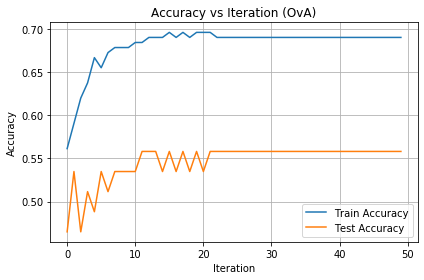

In [111]:
# Accuracy vs Iteration (OvA)
plt.figure()
plt.plot(accs_ova_train, label='Train Accuracy')
plt.plot(accs_ova_test, label='Test Accuracy')
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Iteration (OvA)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

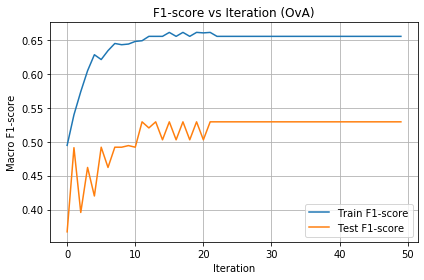

In [112]:
# F1-score vs Iteration (OvA)
plt.figure()
plt.plot(f1s_ova_train, label='Train F1-score')
plt.plot(f1s_ova_test, label='Test F1-score')
plt.xlabel("Iteration")
plt.ylabel("Macro F1-score")
plt.title("F1-score vs Iteration (OvA)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

According to the plot of Accuracy v.s. Iteration, the accuracy of the model on the training set increases quickly with increasing number of iterations and stabilizes at about 69% after about 22 iterations. For the test set, the accuracy values fluctuate more, reaching a high of about 56%, but then it does not continue to increase as the number of iterations rises significantly. This indicates that the model learned the pattern on the training set, but the performance on the test set is poor.

Similarly, the trend of the F1-score also illustrates the same problem. The F1-score on the training set is stable at around 66%, while the F1-score on the test set is stable at around 53%.

By combining the two plots, we can see that Ova Logistic Regression can converge quickly on the training set. However, due to its simple structure, its performance is limited when the linear boundaries cannot distinguish all categories well. It may also have slight overfitting . The training is significantly better than the test, but there is no more room for the model to continue learning.

In [170]:
import numpy as np

print(f"Best training accuracy reached at iteration: {np.argmax(accs_ova_train)}")
print(f"Best test accuracy reached at iteration: {np.argmax(accs_ova_test)}")
print(f"Best training F1-score reached at iteration: {np.argmax(f1s_ova_train)}")
print(f"Best test F1-score reached at iteration: {np.argmax(f1s_ova_test)}")

Best training accuracy reached at iteration: 15
Best test accuracy reached at iteration: 11
Best training F1-score reached at iteration: 17
Best test F1-score reached at iteration: 11


Based on the output, the accuracy for training reaches peak at iteration 15. The f1-score of training set reaches its maximam at iteration 17. For both accuracy an f1-score, the values for test set are maximized at iteration 11. This indicates that the performence of model on the test set does not counituously increase with the increase of the number of iteration. However, the measures for the training set continue to increase. This suggests the model fit the training set better with the increase of the number of iteration, but may not perform better on test set. Therefore, we will use `max_iter = 11` in following OvA logistic regression model in this project to get best performance on the test set.

In [171]:
model_ova_2 = LogisticRegression(max_iter=11, warm_start=True, multi_class='ovr', random_state=7)

ova_acc_train, ova_acc_test, ova_f1_train, ova_f1_test = compute_scores(model_ova_2, X_train, y_train, 
                                                                        X_test, y_test)

print(f"Accuracy for training set: {ova_acc_train:.4f}")
print(f"Accuracy for test set: {ova_acc_test:.4f}")

print(f"F1-score for training set: {ova_f1_train:.4f}")
print(f"F1-score for test set: {ova_f1_test:.4f}")

Accuracy for training set: 0.6959
Accuracy for test set: 0.5581
F1-score for training set: 0.6608
F1-score for test set: 0.5295


Based on the output, for this OvA logistic model, the best accurarcy and f1-score for test set are approximately 0.5581 and 0.5295 respectively. As a linear model, it shows stable classification ability and is suitable as a baseline for following model comparison.

## Support Vector Machine (SVM)  

Next, we used a Support Vector Machine (SVM) model based on Stochastic Gradient Descent (SGD). Similar to the previous logistic regression, I used the One-vs-All approach to extend it to multi-class classification. This approach is not only fast, but also supports round-by-round training[4]. Therefore, I recorded the accuracy and F1-score of the model in each round to see how the model performance changes with the training progress.

Compared to logistic regression, SVM should be able to fit the boundaries better, especially when the categories are not perfectly linearly separable from each other. However, since it is still a linear model, its performance may be limited under more complex boundaries.

In [139]:
from sklearn.linear_model import SGDClassifier

# SVM model
model_svm = SGDClassifier(max_iter=1, warm_start=True, tol=None, random_state=7)


n_iter = 100
accs_svm_train = []
accs_svm_test = []
f1s_svm_train = []
f1s_svm_test = []

for i in range(n_iter):
    acc_train, acc_test,f1_train,f1_test = compute_scores(model_svm, X_train, y_train, X_test, y_test)
    
    accs_svm_train.append(acc_train)
    accs_svm_test.append(acc_test)
    
    f1s_svm_train.append(f1_train)
    f1s_svm_test.append(f1_test)

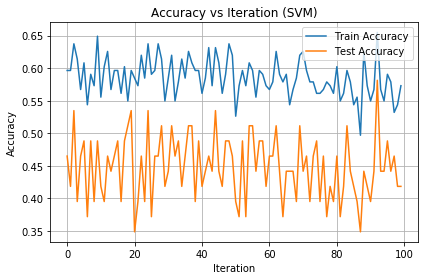

In [140]:
# Accuracy vs Iteration (SVM)
plt.figure()
plt.plot(accs_svm_train, label='Train Accuracy')
plt.plot(accs_svm_test, label='Test Accuracy')
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Iteration (SVM)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

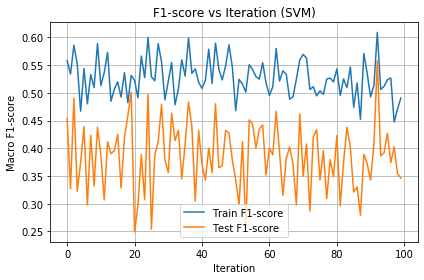

In [141]:
# F1-score vs Iteration (SVM)
plt.figure()
plt.plot(f1s_svm_train, label='Train F1-score')
plt.plot(f1s_svm_test, label='Test F1-score')
plt.xlabel("Iteration")
plt.ylabel("Macro F1-score")
plt.title("F1-score vs Iteration (SVM)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

According to both graphs, the accuracy and F1-score fluctuate a lot with different number of iterations, especially for the test set. The score of the training set, although overall higher than the test set, shows a lot of fluctuations. This indicates that the model may have learned different combinations of features in different rounds. The fluctuation of scores on the test set is more obvious, indicating that the model is not stable enough to predict new samples. This is because the `SGDClassifier` model is trained based on stochastic gradient descent, where only a small number of parameters are updated in each iteration, and thus it is sensitive to the sample order, initial state, and step size[4].

In order to obtain a more stable model with better convergence, I adjusted the parameters and retrained an SVM model with `max_iter=1000` and `learning_rate='optimal'`. This configuration allows the model to perform the gradient update process in its entirety, which is beneficial for convergence.

In [166]:
model_svm_2 = SGDClassifier(max_iter=1000, learning_rate='optimal', random_state=7)

svm_acc_train, svm_acc_test,svm_f1_train,svm_f1_test = compute_scores(model_svm_2, X_train, y_train, 
                                                                              X_test, y_test)
print(f"Accuracy for training set: {svm_acc_train:.4f}")
print(f"Accuracy for test set: {svm_acc_test:.4f}")
print(f"F1-Score for training set:{svm_f1_train:.4f}")
print(f"F1-Score for test set:{svm_f1_test:.4f}")

Accuracy for training set: 0.6725
Accuracy for test set: 0.5349
F1-Score for training set:0.6415
F1-Score for test set:0.5079


Although SVM should theoretically be better than logistic regression in terms of fitting results, this is not the case in this project. Based on the output, we note that the fully trained SVM model did not perform better than logistic regression. Actually, logistc regression performs slightly better than SVM model. More specifically, both accuracy and F1-score of the test set for SVM were silghtly lower than logistic eegression. This indicates that the SVM model has not sufficiently learned the boundaries that can effectively distinguish between different glass types.

This may be related to the training method of the SVM model. I used `SGDClassifier` to implement the linear SVM, which is sensitive to the learning rate, data distribution, and class imbalance [4]. Although a large number of iterations and a suitable learning rate strategy were set, the model's prediction on the test set was still unstable.

All things considered, logistic regression performs more stably in this task. This result also indicates that for tasks with small sample sizes and relatively simple classes distributions, basic models such as logistic regression may perform more stably and reliably.

## Random Forest  

The random forest can improve the performance of a model by building multiple decision trees and voting on their predictions. Since each tree is trained on a different subset of the training set, it can improve accuracy while reducing the possibility of overfitting. Compared to the previous two models, the random forest is a nonlinear model that is more suitable for tasks where there are complex relationships between features.  Then, I will use the random forest model to classify the glass and see the difference in prediction results between the nonlinear and linear models. Moreover, I will also plot the performance changes of the model on the training and test sets at different max tree depths (`max_depth`), which will be used to see if the model is overfitting or underfitting.

In [158]:
from sklearn.ensemble import RandomForestClassifier

depth_range = range(1, 21)

accs_rf_train = []
accs_rf_test = []
f1s_rf_train = []
f1s_rf_test = []

for k in depth_range:
    model_rf = RandomForestClassifier(max_depth=k, random_state=7)
    acc_train, acc_test,f1_train,f1_test = compute_scores(model_rf, X_train, y_train, X_test, y_test)
    
    accs_rf_train.append(acc_train)
    accs_rf_test.append(acc_test)
    
    f1s_rf_train.append(f1_train)
    f1s_rf_test.append(f1_test)

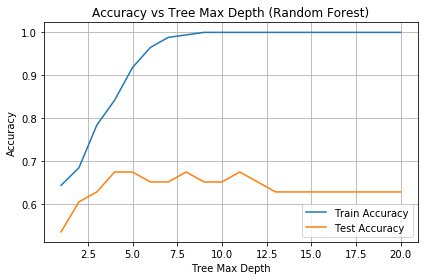

In [159]:
# Accuracy vs Tree Max Depth (Random Forest)
plt.figure()
plt.plot(depth_range,accs_rf_train, label='Train Accuracy')
plt.plot(depth_range,accs_rf_test, label='Test Accuracy')
plt.xlabel("Tree Max Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Tree Max Depth (Random Forest)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

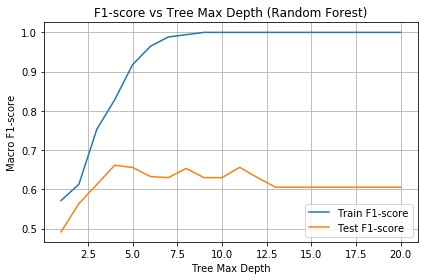

In [160]:
# F1-score vs Tree Max Depth (Random Forest)
plt.figure()
plt.plot(depth_range,f1s_rf_train, label='Train F1-score')
plt.plot(depth_range,f1s_rf_test, label='Test F1-score')
plt.xlabel("Tree Max Depth")
plt.ylabel("Macro F1-score")
plt.title("F1-score vs Tree Max Depth (Random Forest)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Based on the output, the accuracy and f1-score for trainning set quickly approach to 1 with the tree depth increases. This indicates the random forest model is perfectly fitted on the training set. However, for test set, the value of accuracy and f1-score reaches their peaks (both around 66%) at tree max depth of about 4. Then, both accuary and f1-score begin to fluctuate and gradually decreases, eventually stabilizing. This indicates that as the tree max depth increases, the model begins to overfit. This suggests although the performanc of model on the training set is good, the performance on test set becomes poor.

To sum up, the performance of random forest is better than the previous models. This indicates that for this project, the performance of nonlinear model is stronger. However, it is also more likely to overfit, so we need to find a balance between performance and stability by adjusting the `max_depth` and other parameters.

In [163]:
depths = list(depth_range)

# best accuracy
print(f"Best Depth for Train Accuracy: {depths[np.argmax(accs_rf_train)]}")
print(f"Best Depth for Test Accuracy: {depths[np.argmax(accs_rf_test)]}")

# best f1
print(f"Best Depth for Train F1-score: {depths[np.argmax(f1s_rf_train)]}")
print(f"Best Depth for Test F1-score: {depths[np.argmax(f1s_rf_test)]}")

Best Depth for Train Accuracy: 9
Best Depth for Test Accuracy: 4
Best Depth for Train F1-score: 9
Best Depth for Test F1-score: 4


Based on the output, for both accuracy and f1-score, the best tree max depth for training set is 9. At this time, the model is approximately perfectly fitted on the training set. However, for test set, the best tree max depth for both accuarcy and f1-score is 4. This indicats incresing the tree max depth does not increase the ability to predict the class for new data, but may bring overfitting. Therefore, we will use `max_depth = 4` in following random forest model in this project to get best performance on the test set.

In [168]:
model_rf_2 = RandomForestClassifier(max_depth=4, random_state=7)

rf_acc_train, rf_acc_test, rf_f1_train, rf_f1_test = compute_scores(model_rf_2, X_train, y_train, X_test, y_test)

print(f"Accuracy for training set: {rf_acc_train:.4f}")
print(f"Accuracy for test set: {rf_acc_test:.4f}")
print(f"F1-Score for training set:{rf_f1_train:.4f}")
print(f"F1-Score for test set:{rf_f1_test:.4f}")

Accuracy for training set: 0.8421
Accuracy for test set: 0.6744
F1-Score for training set:0.8282
F1-Score for test set:0.6613


Based on the output, the best accuracy and f1-score for test set are 0.6744 and 0.6613 repectively. Compared with the values for previous models, there is a noticeable improvement. Therefore, the performance of random forest model is much better than previous linear model.

## XGBoost

In this section, we used the XGBoost (Extreme Gradient Boosting) algorithm for muti-class classification. Unlike random forests, XGBoost does not learn all the trees at once, but rather corrects previous mistakes step by step[5]. We will try different depths of the tree at first, observe how it performs on the training set and the test set, and then pick the model that works best for the final evaluation.

In [177]:
# pip install xgboost
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# The label must consist of integer labels of form 0, 1, 2, ..., [num_class - 1].
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

depth_range = range(1, 21)

accs_xgb_train = []
accs_xgb_test = []
f1s_xgb_train = []
f1s_xgb_test = []

for k in depth_range:
    model_xgb = XGBClassifier(max_depth=k, objective='multi:softmax', num_class=len(np.unique(y_train)), 
                              use_label_encoder=False, eval_metric='mlogloss', random_state=7)
    
    acc_train, acc_test,f1_train,f1_test = compute_scores(model_xgb, X_train, y_train_encoded, 
                                                          X_test, y_test_encoded)
    
    accs_xgb_train.append(acc_train)
    accs_xgb_test.append(acc_test)
    
    f1s_xgb_train.append(f1_train)
    f1s_xgb_test.append(f1_test)

For this XGB model, we set `objective = 'multi:softmax'` becasue it is a multi-class classification. There are several types of class in this dataset, and `softmax` means that the model outputs the one with the highest probability of being in a class as a prediction. Then, we set `num_class=len(np.unique(y_train))`, which means to tell the model the number of class by calculating the number of labels in the training set. Since we already encode our data to make sure it fits this XGB model, we set `use_label_encoder=False`. Finally, `mlogloss` is a common method for XGB to evaluate model in multi-class task[6].

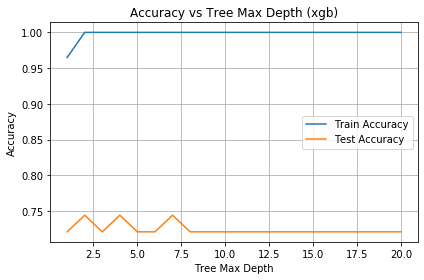

In [178]:
# Accuracy vs Tree Max Depth (xgb)
plt.figure()
plt.plot(depth_range, accs_xgb_train, label='Train Accuracy')
plt.plot(depth_range, accs_xgb_test, label='Test Accuracy')
plt.xlabel("Tree Max Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Tree Max Depth (xgb)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

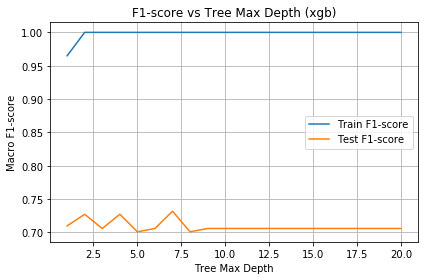

In [179]:
# F1-score vs Tree Max Depth (xgb)
plt.figure()
plt.plot(depth_range,f1s_xgb_train, label='Train F1-score')
plt.plot(depth_range,f1s_xgb_test, label='Test F1-score')
plt.xlabel("Tree Max Depth")
plt.ylabel("Macro F1-score")
plt.title("F1-score vs Tree Max Depth (xgb)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Based on the outputs, we observed that for both accuracy and f1-score, the XGB model performs almost perfectly on the training set. This suggest the model may have memerized all the data from the training set. Compared with values for the test set, although there is significant improvement for both accuracy and f1-scores, there are noticable gaps between the training set and the test set. The accuracy for the test set reaches its maximum (approximately 74%) when the tree max depth is 2. Also, the f1-score for the test set maximizaed (approximately 73%) when the trr max depth is 7. This suggests the model is a slightly overfitted. However, the performance of this model is better than all previous models on both accuracy and f1-score. Also, based on the plots, the model is also stable. This suggests that this model is more effective than previous models

In [180]:
depths = list(depth_range)

# best accuracy
print(f"Best Depth for Train Accuracy: {depths[np.argmax(accs_xgb_train)]}")
print(f"Best Depth for Test Accuracy: {depths[np.argmax(accs_xgb_test)]}")

# best f1
print(f"Best Depth for Train F1-score: {depths[np.argmax(f1s_xgb_train)]}")
print(f"Best Depth for Test F1-score: {depths[np.argmax(f1s_xgb_test)]}")

Best Depth for Train Accuracy: 2
Best Depth for Test Accuracy: 2
Best Depth for Train F1-score: 2
Best Depth for Test F1-score: 7


Based on the output, for both accuracy and f1-score, the best tree max depth for training set is 2. At this time, the model is approximately perfectly fitted on the training set. However, for test set, the best tree max depth for accuarcy and f1-score are 2 and 7 respectively. In this case, since the distribution of glass classes in this dataset is unbalanced, we should choose `max_depth = 7` to make sure the model is performs well in all classes in the test set.

In [183]:
model_xgb_2 = XGBClassifier(max_depth=7, objective='multi:softmax', num_class=len(np.unique(y_train)), 
                          use_label_encoder=False, eval_metric='mlogloss', random_state=7)

xgb_acc_train, xgb_acc_test, xgb_f1_train, xgb_f1_test = compute_scores(model_xgb_2, X_train, y_train_encoded, 
                                                                        X_test, y_test_encoded)

print(f"Accuracy for training set: {xgb_acc_train:.4f}")
print(f"Accuracy for test set: {xgb_acc_test:.4f}")
print(f"F1-Score for training set:{xgb_f1_train:.4f}")
print(f"F1-Score for test set:{xgb_f1_test:.4f}")

Accuracy for training set: 1.0000
Accuracy for test set: 0.7442
F1-Score for training set:1.0000
F1-Score for test set:0.7317


Based on the output, the best accuracy and f1-score for test set are 0.7442 and 0.7317 repectively. Compared with the values for previous models, there is a noticeable improvement. Therefore, the performance of XGBoost model is much better than all previous models.

## Neural Network

In addition, we try to use a neural network model to complete the task of classifying glass classes. In short, a neural network is a model consisting of a bunch of “layers”, each of them processing the data with a little bit, overlapping the layers, and finally giving a prediction result. Compared with the previous model, it is more suitable for dealing with those situations where the relationship between features is more complex.

In [200]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# One-hot code
y_train_one = to_categorical(y_train)
y_test_one = to_categorical(y_test)

# model
model_nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)), 
    Dropout(0.3), # drop out layer with dropout rate of 30%
    Dense(32, activation='relu'),
    Dropout(0.3), # drop out layer with dropout rate of 30%
    Dense(y_train_cat.shape[1], activation='softmax')
])

The first layer is a hidden layer with 64 neurons, using the ReLU activation function. Besides, the shape of the input is set to be consistent with the number of features in the training data. To prevent the model from overfitting, we add a `Dropout` layer after this layer, which randomly “drops” 30% of the neurons [7]. Next is a second hidden layer with 32 neurons. This layer also uses the ReLU activation function and is followed by same `Dropout` layer. Finally, there is an output layer with the same number of neurons as the number of categories, which uses a softmax activation function to output the predicted probability for each category. 

The reason for choosing this structure is to find a balance between a model that is not too simple and not too complex, to avoid learning too much. This structure is relatively simple, but can guarantee a certain expression ability, suitable for this size of dataset.

In [201]:
# compile the model
model_nn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

For model compile, we used `Adam` as the optimizer, which is one of the more common optimization methods. For the loss function, we chose `categorical_crossentropy` because it is the most common choice for multiclassification problems, and it is a good measure of the gap between the probability of the output of the model and the true class. Finally, we let the model calculate the accuracy during the training process at the same time. It is convenient to compare the performance of different models.

In [202]:
# train the model
history = model_nn.fit(X_train, y_train_one, epochs=50, batch_size=10, 
                       validation_data=(X_test, y_test_cat), verbose=1)

Epoch 1/50
18/18 [==============================] - 1s 8ms/step - loss: 2.1931 - accuracy: 0.1228 - val_loss: 1.9726 - val_accuracy: 0.1628
Epoch 2/50
18/18 [==============================] - 0s 2ms/step - loss: 1.9429 - accuracy: 0.2632 - val_loss: 1.8013 - val_accuracy: 0.3721
Epoch 3/50
18/18 [==============================] - 0s 2ms/step - loss: 1.7765 - accuracy: 0.3626 - val_loss: 1.6582 - val_accuracy: 0.5116
Epoch 4/50
18/18 [==============================] - 0s 2ms/step - loss: 1.6261 - accuracy: 0.4737 - val_loss: 1.5358 - val_accuracy: 0.4651
Epoch 5/50
18/18 [==============================] - 0s 2ms/step - loss: 1.5351 - accuracy: 0.5322 - val_loss: 1.4480 - val_accuracy: 0.4884
Epoch 6/50
18/18 [==============================] - 0s 2ms/step - loss: 1.4723 - accuracy: 0.5088 - val_loss: 1.3503 - val_accuracy: 0.4884
Epoch 7/50
18/18 [==============================] - 0s 2ms/step - loss: 1.2805 - accuracy: 0.5673 - val_loss: 1.2799 - val_accuracy: 0.4651
Epoch 8/50
18/18 [==

In the training phase, we feed the training data to the model and allow it to learn iteratively over 50 rounds (epochs) and take 10 samples (`batch_size=10`) of the data each time to update it. In this way, the model can optimize its prediction gradually during the learning process. In order to observe the performance of the model on the test set, we also input the `validation_data` at the same time, so that we can directly see the accuracy and loss value on the test set during training. Finally, we set `verbose=1`, so that we can see the progress and results of each round in real time during training.

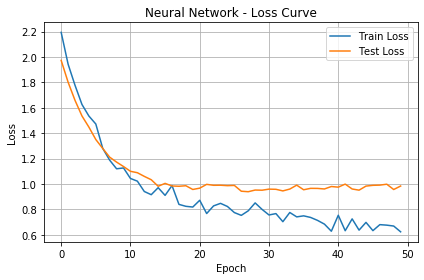

In [203]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title("Neural Network - Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Based on the output, we notice that the train loss deacreases as the epoch increases. This indicates that with the increase in epoch, the model can predict the data on the training set better and better. For test loss, there is a drop at the begining, and it stablizes about 0.9 after epoch 15. This indicates that at the begining, the performance of model on the test set improves, but the effect of continuous training is limited. 

Based on this plot, the performance of this model on test loss does not change too much after epoch 15. So, we can set `epochs = 15` to save training time and avoid overfitting.

In [208]:
model_nn.fit(X_train, y_train_one, epochs=15, batch_size=10, validation_data=(X_test, y_test_cat), verbose=1)

Epoch 1/15
18/18 [==============================] - 0s 3ms/step - loss: 0.5449 - accuracy: 0.8070 - val_loss: 1.0420 - val_accuracy: 0.6512
Epoch 2/15
18/18 [==============================] - 0s 2ms/step - loss: 0.5310 - accuracy: 0.7895 - val_loss: 1.0212 - val_accuracy: 0.6512
Epoch 3/15
18/18 [==============================] - 0s 2ms/step - loss: 0.5736 - accuracy: 0.7836 - val_loss: 1.0238 - val_accuracy: 0.6512
Epoch 4/15
18/18 [==============================] - 0s 2ms/step - loss: 0.5569 - accuracy: 0.7895 - val_loss: 1.0597 - val_accuracy: 0.6512
Epoch 5/15
18/18 [==============================] - 0s 2ms/step - loss: 0.6104 - accuracy: 0.7602 - val_loss: 1.0523 - val_accuracy: 0.6512
Epoch 6/15
18/18 [==============================] - 0s 2ms/step - loss: 0.5197 - accuracy: 0.7953 - val_loss: 1.0522 - val_accuracy: 0.6512
Epoch 7/15
18/18 [==============================] - 0s 2ms/step - loss: 0.4913 - accuracy: 0.8012 - val_loss: 1.0589 - val_accuracy: 0.6512
Epoch 8/15
18/18 [==

In [209]:
# prediction
y_pred_train = model_nn.predict(X_train).argmax(axis=1)
y_pred_test = model_nn.predict(X_test).argmax(axis=1)

# evaluation: accuracy and f1-score
nn_acc_train = accuracy_score(y_train, y_pred_train)
nn_acc_test = accuracy_score(y_test, y_pred_test)
nn_f1_train = f1_score(y_train, y_pred_train, average='weighted')
nn_f1_test = f1_score(y_test, y_pred_test, average='weighted')

print(f"Accuracy for training set: {nn_acc_train:.4f}")
print(f"Accuracy for test set: {nn_acc_test:.4f}")
print(f"F1-score for training set: {nn_f1_train:.4f}")
print(f"F1-score for training set: {nn_f1_test:.4f}")

Accuracy for training set: 0.8480
Accuracy for test set: 0.6512
F1-score for training set: 0.8406
F1-score for training set: 0.6313


Based on the output, the best accuracy and f1-score for test set are 0.6512 and 0.6313 repectively. Overall, this neural network model still performs slightly better than some of the previous models, and is especially slightly more stable in terms of balancing the performance on the training set and the test set.

## Models Comparison

After completing the evaluation of each model, I organized their performance on the test set and compared them from two perspectives: accuracy and F1-score. These two measures provide a more comprehensive representation of the classification performance of the models: the Accuracy focuses on whether the overall prediction is correct, while the F1-score emphasizes the balanced performance of the models on each class, especially their ability to recognize a small number of classes.

In order to visualize the strengths and weaknesses of each model, we plotted accuracy and f1-score against each other on the test set for different models, and additionally compared the difference between the two. These plots help me to more clearly determine which model is better suited for this multi-classification task.

In [211]:
models = ['OvA', 'SVM', 'Random Forest', 'XGBoost', 'Neural Network']
accs = [ova_acc_test, svm_acc_test, rf_acc_test, xgb_acc_test, nn_acc_test]
f1s = [ova_f1_test, svm_f1_test, rf_f1_test, xgb_f1_test, nn_f1_test]

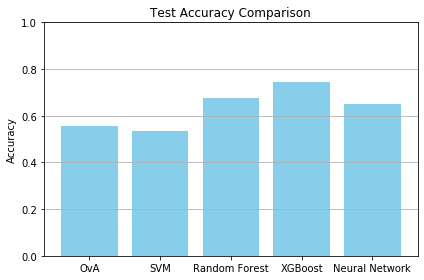

In [213]:
plt.figure()
plt.bar(models, accs, color='skyblue')
plt.title('Test Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

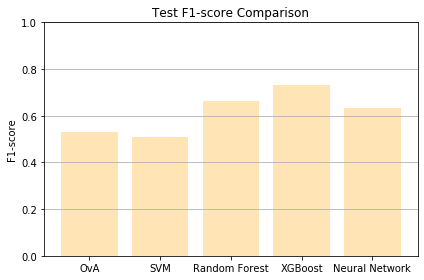

In [219]:
plt.figure()
plt.bar(models, f1s, color='moccasin')
plt.title('Test F1-score Comparison')
plt.ylabel('F1-score')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

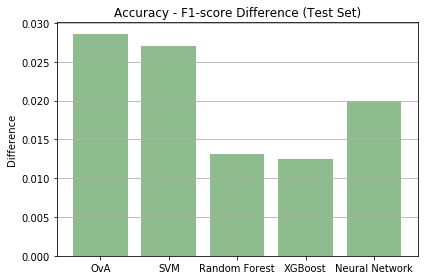

In [220]:
accs_f1s_diff = [a - f for a, f in zip(accs, f1s)]

plt.figure()
plt.bar(models, accs_f1s_diff, color='darkseagreen')
plt.title('Accuracy - F1-score Difference (Test Set)')
plt.ylabel('Difference')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Based on the plot for accuracy on test set, the accuracy for XGB model is the highest, then followed by random forest model and neural network model. Both Ova model and SVM model perform relatively poorly on accurarcy. Next, for the plot of f1-score on test, the rank is the same as the rank for accuracy plot. The SGB model is still in the lead, then followed by random forest model and neral network model. The OvA model and SVM model are the last. Finally, for difference plot, the SGBoot model also the least difference between accuracy and f1-score. This indicates that the model prediction is consistent across different classes. The differences for random forest model and neural network are relatively low, while the differences for both OvA and SVM are high. Therefore, the XGBoost model has the best performance, followed by random forest model and neural networks model are slightly poorer but still competitive, while OvA model and SVM model are relatively weak.

# Conclusion

In conclusion, the best model for this glass classification task is the XGBoost model `model_xgb_2`, which has the highest accuracy and f1-score on the test set. This indicates that it learns the patterns in the data relatively well and doesn't overfit easily. Once the parameters are tuned, its performance is stable. However,it has a lot of parameters, and the process of tuning parameters can be quite time-consuming. Besides, the training speed is not so fast, especially after the data volume becomes larger. In addition, if you take it to the actual scenario, the implementation is not as light as logistic regression or decision tree, which may bring pressure on computing resources. Finally, if the format of the input data is not standardized, for example, there are missing values, outliers are not handled properly, the model will be easy to be unstable, so the data cleaning in the early stage is also very critical for this model.

# References

[1] German, B. (1987). Glass Identification [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5WW2P.

[2] Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

[3] Sefidian, A. M. (2022, June 19). Understanding micro, macro, and weighted averages for scikit-learn metrics in multi-class classification with example. Retrieved April 20, 2025, from https://iamirmasoud.com/2022/06/19/understanding-micro-macro-and-weighted-averages-for-scikit-learn-metrics-in-multi-class-classification-with-example/

[4] GeeksforGeeks. (2023, November 4). Stochastic Gradient Descent Classifier. https://www.geeksforgeeks.org/stochastic-gradient-descent-classifier/

[5] GeeksforGeeks. (2025, February 2). XGBoost. https://www.geeksforgeeks.org/xgboost/

[6] XGBoost Developers. (2022). Get started with XGBoost. https://xgboost.readthedocs.io/en/stable/get_started.html

[7] GeeksforGeeks. (2024, June 19). Implementing Dropout in TensorFlow. https://www.geeksforgeeks.org/implementing-dropout-in-tensorflow/